In [6]:
import numpy as np
import cv2 
import matplotlib.pyplot as plt


In [7]:
data = np.arange(6).reshape(2, 3)

print(data)

i, j = 1, 2
print(data[i][j])

[[0 1 2]
 [3 4 5]]
5


In [8]:
width, height = 3, 2
data = np.arange(0, 6).reshape(2, 3)
print(data)
pad = np.array([0, height - 1])
transform = np.array([
    [1, 0],
    [0, -1]
])

out_put = np.zeros((height, width))
for x2 in range(height):
    for x1 in range(width):
        v = np.array([x1, x2])
        color = data[x2][x1]
        new_x1, new_x2 = transform.dot(v) + pad
        out_put[new_x2, new_x1] = color
print(out_put)

[[0 1 2]
 [3 4 5]]
[[3. 4. 5.]
 [0. 1. 2.]]


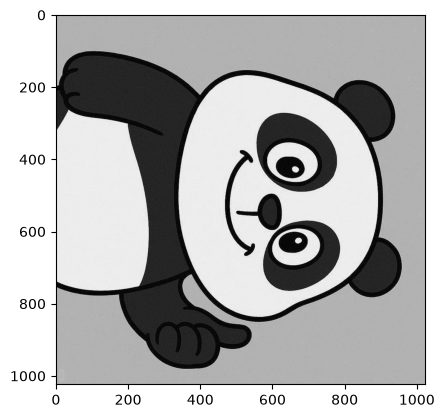

In [9]:
image = cv2.imread('output.jpg', 0)
height = len(image)
width = len(image[0])
transform = np.array([
    [0, -1],
    [1, 0]
])
result = np.zeros((height, width))
pad = np.array([width - 1, 0])
for x2 in range(height):
    for x1 in range(width):
        v = np.array([x1, x2])
        color = image[x2, x1]
        new_x1, new_x2 = transform.dot(v) + pad
        result[new_x2, new_x1] = color

plt.imshow(result, cmap='gray')

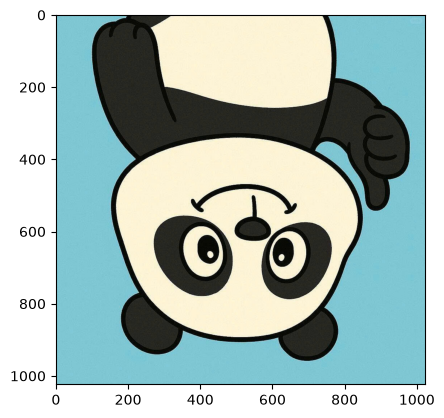

In [10]:
image = cv2.imread('7.jpg', 1)
height = len(image)
width = len(image[0])
transform = np.array([
    [1, 0],
    [0, -1]
])
result = np.zeros((height, width, 3))
pad = np.array([0, height - 1])
for x2 in range(height):
    for x1 in range(width):
        v = np.array([x1, x2])
        color = image[x2,x1,:]
        new_x1, new_x2 = transform.dot(v) + pad
        result[new_x2, new_x1] = color
result = result.astype(np.uint8)
plt.imshow(result[:,:,[2, 1, 0]])

In [11]:
A = np.array([
    [6.7, 1],
    [4.6, 1],
    [3.5, 1],
    [5.5, 1]
])
B = np.array([9.1, 5.9, 4.6, 6.7])

ATA = np.dot(A.T, A)

d_value = np.linalg.det(ATA)
ATAminus1 = np.linalg.inv(ATA)

x = np.dot(ATAminus1, np.dot(A.T, B))

print(x)

[ 1.37268204 -0.39136137]


In [12]:
x = np.array(
    [6.7, 4.6, 4.5, 5.5]
)
y = np.array([9.1, 5.9, 4.6, 6.7])
A = np.vstack([x, np.ones(len(x))]).T
print(A)
w, b = np.linalg.lstsq(A, y, rcond = None)[0]
print(w, b)

[[6.7 1. ]
 [4.6 1. ]
 [4.5 1. ]
 [5.5 1. ]]
1.7945643485211829 -2.981055155875299


In [13]:
vector1 = np.array([5, 3, 2, 7])
vector2 = np.array([2, 9, 4, 1])
dproduct = np.dot(vector1, vector2)
norm_1 = np.linalg.norm(vector1)
norm_2 = np.linalg.norm(vector2)

cos_sim = dproduct / (norm_1 * norm_2)
print(cos_sim)

0.552005787925351


In [14]:
def cosine_similarity(vector1, vector2):
    sumxy = sum([v1 * v2 for v1, v2 in zip(vector1, vector2)])
    sumxx = sum([v1 * v2 for v1, v2 in zip(vector1, vector1)])
    sumyy = sum([v1 * v2 for v1, v2 in zip(vector2, vector2)])
    return sumxy / ((sumxx * sumyy) ** 0.5)
vector1 = [5, 3, 2, 7]
vector2 = [2, 9, 4, 1]

output = cosine_similarity(vector1, vector2)
print(output)

0.552005787925351


In [15]:
#Algebra
x = np.array([0, 5])
y = np.array([3, 3])

dproduct = np.dot(x, y)
print(dproduct)

15


In [16]:
#Geometry
x_length = np.linalg.norm(x)
y_length = np.linalg.norm(y)
cos_xy = np.cos(np.pi / 4)
dproduct = x_length * y_length * cos_xy
print(dproduct)

14.999999999999998


In [17]:
img1 = cv2.imread('6.traffic_sign/sign1.png')
img1 = cv2.resize(img1, (100, 100))

img2 = cv2.imread('6.traffic_sign/sign5.png')
img2 = cv2.resize(img2, (100, 100))

img3 = cv2.imread('6.traffic_sign/sign3.png')
img3 = cv2.resize(img3, (100, 100))

img4 = cv2.imread('6.traffic_sign/sign4.png')
img4 = cv2.resize(img4, (100, 100))

print(img1.shape)
print(img2.shape)
print(img3.shape)
print(img4.shape)

(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)


In [18]:
L1_s1_s2 = np.sum(np.abs(img1 - img2)) / (100 * 100 * 3)
print(L1_s1_s2)

50.567166666666665


In [19]:
L1_s1_s3= np.sum(np.abs(img1 - img3)) / (100 * 100 * 3)
print(L1_s1_s3)

171.84026666666668


In [20]:
L1_s1_s4= np.sum(np.abs(img1- img4)) / (100 * 100 * 3)
print(L1_s1_s4)

90.49526666666667


In [ ]:
from numpy.linalg import norm
def cos_sim(x, y):
    x = x.flatten()
    y = y.flatten()

    x = x.astype(np.float64)
    y = y.astype(np.float64)

    cos_sim = np.dot(x, y) / (norm(x) * norm(y))
    return cos_sim



print(cos_sim(img1, img2))
print(cos_sim(img1, img3))
print(cos_sim(img1, img4))


0.9999999999999998
0.5750955260394579
0.9669706203695292
